Fake News Detection using Machine Learning

Exploratory Data Analysis (EDA)

This notebook performs the Exploratory Data Analysis (EDA) on the Fake and Real News dataset before applying Natural Language Processing and Machine Learning techniques.

In [41]:
## 1. Import Required Libraries

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [43]:
## 2. Load & Insspect Dataset

In [44]:
fake = pd.read_csv("data/Fake.csv")
true = pd.read_csv("data/True.csv")

In [45]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [46]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [47]:
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [48]:
print(fake.columns)

print(true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [49]:
fake.info()

true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [50]:
## 3. Missing Values

In [51]:
print("Fake Dataset")
print(fake.isnull().sum())

print("\nTrue Dataset")
print(true.isnull().sum())

Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64

True Dataset
title      0
text       0
subject    0
date       0
dtype: int64


In [52]:
## 4. Duplicate Records

In [53]:
print("Fake duplicates :", fake.duplicated().sum())
print("True duplicates :", true.duplicated().sum())

Fake duplicates : 3
True duplicates : 206


In [54]:
fake.drop_duplicates(inplace=True)

true.drop_duplicates(inplace=True)

In [55]:
## 5. Add Labels

In [56]:
fake["label"] = 0

true["label"] = 1

In [57]:
## 6. Merge Dataset

In [58]:
df = pd.concat([fake, true], ignore_index=True)

In [59]:
## 7. Shuffle Dataset

In [60]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [61]:
## 8. Class Distribution

In [62]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

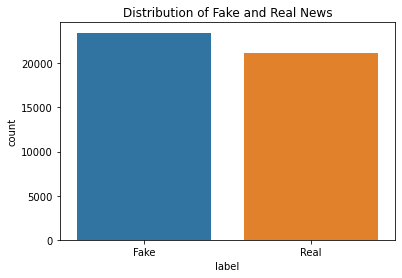

In [63]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Fake and Real News")

plt.xticks([0,1],["Fake","Real"])

plt.show()

In [64]:
## 9. Statistics

In [65]:
df["text_length"] = df["text"].apply(len)
print(df["text_length"])

0        10062
1         2808
2          232
3          610
4         2658
         ...  
44684     1428
44685        1
44686     5016
44687     5060
44688     4371
Name: text_length, Length: 44689, dtype: int64


In [66]:
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

In [67]:
## 10. Distribution of Article Length

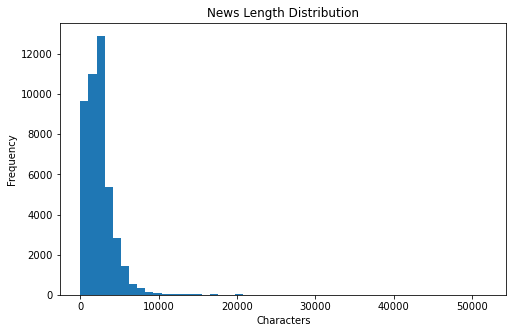

In [68]:
plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=50)

plt.title("News Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [69]:
## 11. Title Length

In [70]:
df["title_length"] = df["title"].apply(len)
print(df["title_length"])

0        134
1         69
2         78
3         84
4         74
        ... 
44684     90
44685     85
44686     55
44687     98
44688    108
Name: title_length, Length: 44689, dtype: int64


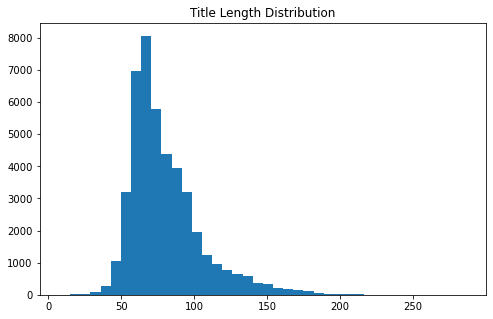

In [71]:
plt.figure(figsize=(8,5))

plt.hist(df["title_length"], bins=40)

plt.title("Title Length Distribution")

plt.show()

In [72]:
## 12. Subject Distribution

In [73]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

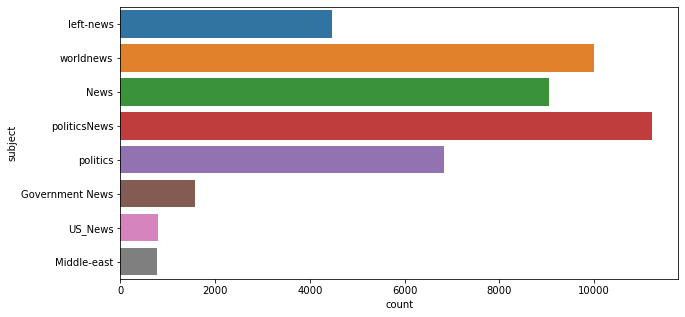

In [74]:
plt.figure(figsize=(10,5))

sns.countplot(y="subject", data=df)

plt.show()

In [75]:
## 13. Correlation

In [76]:
numeric = df[["title_length","text_length","label"]]

numeric.corr()

,title_length,text_length,label
title_length,1.000000,0.032815,-0.580478
text_length,0.032815,1.000000,-0.038944
label,-0.580478,-0.038944,1.000000


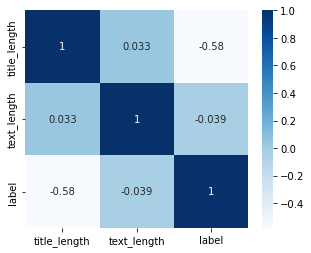

In [77]:
plt.figure(figsize=(5,4))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="Blues")

plt.show()

In [78]:
## 14. Save Clean Dataset

In [79]:
df.to_csv("data/merged_news.csv", index=False)